In [1]:
%pip install pyarrow pandas requests python-louvain

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import pandas as pd
import numpy as np
from datetime import datetime
from collections import Counter
import re

import networkx as nx
import community
import pickle

import matplotlib.pyplot as plt

In [3]:
# Check if reddit dataset exists locally

original_dataset_path = "data/reddit_gaming_madoc.parquet"

if not os.path.exists(original_dataset_path):
    raise FileNotFoundError(
        f"Please download the `reddit_gaming_madoc.parquet` dataset from Zenodo and place it at {original_dataset_path}\n"
        "See README for instructions."
    )

In [5]:
# Load the full dataset
df = pd.read_parquet(original_dataset_path)

# Take first 100 rows
df_sample = df.head(100)

# Save as new parquet file
sample_output_path = "data/reddit_gaming_sample_100.parquet"
df_sample.to_parquet(sample_output_path, index=False)

print(f"Original dataset rows: {len(df):,}")
print(f"Sample rows saved: {len(df_sample)}")
print(f"Saved to: {sample_output_path}")

Original dataset rows: 44,274,130
Sample rows saved: 100
Saved to: data/reddit_gaming_sample_100.parquet


In [4]:
# Load your data
df = pd.read_parquet(original_dataset_path)

print("=" * 80)
print("MADOC DATASET - COMPLETE OVERVIEW")
print("=" * 80)

# Dataset size
print("\n📊 DATASET SIZE:")
print(f"   Total rows: {len(df):,}")
print(f"   Total columns: {len(df.columns)}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Date ranges
if 'publish_date' in df.columns:
    print("\n📅 DATE RANGE:")
    min_ts = df['publish_date'].min()
    max_ts = df['publish_date'].max()
    min_date = pd.to_datetime(min_ts, unit='s')
    max_date = pd.to_datetime(max_ts, unit='s')
    
    print(f"   From: {min_date} (Timestamp: {min_ts})")
    print(f"   To:   {max_date} (Timestamp: {max_ts})")
    print(f"   Duration: {(max_date - min_date).days} days")
    
    # Date distribution by year/month
    df['year'] = pd.to_datetime(df['publish_date'], unit='s').dt.year
    df['month'] = pd.to_datetime(df['publish_date'], unit='s').dt.month
    print(f"\n   Records by year:")
    year_counts = df['year'].value_counts().sort_index()
    for year, count in year_counts.items():
        print(f"     {year}: {count:,} ({count/len(df)*100:.1f}%)")

# Analyse columns
if 'community' in df.columns:
    print("\n🏘️ COMMUNITY BREAKDOWN:")
    print(f"   Total unique communities: {df['community'].nunique():,}")

if 'interaction_type' in df.columns:
    print("\n💬 INTERACTION TYPES:")
    type_counts = df['interaction_type'].value_counts()
    for interaction_type, count in type_counts.items():
        print(f"   {interaction_type}: {count:10,} ({count/len(df)*100:.1f}%)")
    
    # post-to-comment ratio
    if 'POST' in type_counts.index and 'COMMENT' in type_counts.index:
        post_count = type_counts['POST']
        comment_count = type_counts['COMMENT']
        print(f"\n   Post-to-Comment Ratio: 1:{comment_count/post_count:.1f}")

# Check user interactions
if 'user_id' in df.columns:
    print("\n👥 USER STATISTICS:")
    print(f"   Unique users: {df['user_id'].nunique():,}")
    
    # Posts per user distribution
    user_activity = df['user_id'].value_counts()
    print(f"   Avg interactions per user: {user_activity.mean():.2f}")
    print(f"   Median interactions per user: {user_activity.median():.2f}")
    print(f"   Max interactions by one user: {user_activity.max():,}")
    
    # Power users (top 1%)
    top_1_percent = int(len(user_activity) * 0.01)
    print(f"   Top 1% users produce: {user_activity.head(top_1_percent).sum():,} interactions ({user_activity.head(top_1_percent).sum()/len(df)*100:.1f}% of total)")

# Display sample dataset
columns_to_show = ['post_id', 'publish_date', 'user_id', 'parent_id', 'parent_user_id', 'community', 'interaction_type', 'content']

df_display = df.copy()
if 'publish_date' in df_display.columns:
    df_display['publish_date'] = pd.to_datetime(df_display['publish_date'], unit='s')

# Display 20 random rows 
pd.set_option('display.max_colwidth', 100)
print(df_display.sample(20)[columns_to_show])

# Check for invalid data in dataset
print("\n" + "=" * 80)
print("DATA QUALITY REPORT")
print("=" * 80)

print("\n⚠️ Missing values percentage:")
for col in df.columns:
    missing_pct = (df[col].isnull().sum() / len(df)) * 100
    if missing_pct > 0:
        print(f"   {col}: {missing_pct:.1f}%")

# Check missing content 
missing_content = df['content'].isna().sum() + (df['content'] == '<NA>').sum() + (df['content'] == 'na').sum()
print(f"Actual missing content rows: {missing_content}")

# Check for duplicates
if 'post_id' in df.columns:
    duplicates = df['post_id'].duplicated().sum()
    print(f"\n   Duplicate post_ids: {duplicates:,} ({duplicates/len(df)*100:.3f}%)")

# Check if emojis are actually in the data
# Find rows with potential emojis (Unicode 1F300-1F9FF range)
emoji_pattern = re.compile(r'[\U0001F300-\U0001F9FF]')
df['has_emoji'] = df['content'].apply(lambda x: bool(emoji_pattern.search(str(x))))

print(f"Rows with emojis: {df['has_emoji'].sum():,}")
print(df[df['has_emoji']][['content']].head(5))

# Check for data types issues
print(f"\n✅ Data types check:")
for col in df.columns:
    print(f"   {col}: {df[col].dtype}")

MADOC DATASET - COMPLETE OVERVIEW

📊 DATASET SIZE:
   Total rows: 44,274,130
   Total columns: 16
   Memory usage: 32189.15 MB

📅 DATE RANGE:
   From: 2014-01-01 00:00:04 (Timestamp: 1388534404)
   To:   2020-12-31 23:59:57 (Timestamp: 1609459197)
   Duration: 2556 days

   Records by year:
     2014: 4,842,491 (10.9%)
     2015: 4,733,256 (10.7%)
     2016: 4,961,830 (11.2%)
     2017: 6,255,734 (14.1%)
     2018: 8,184,988 (18.5%)
     2019: 7,578,095 (17.1%)
     2020: 7,717,736 (17.4%)

🏘️ COMMUNITY BREAKDOWN:
   Total unique communities: 1

💬 INTERACTION TYPES:
   COMMENT: 41,386,090 (93.5%)
   POST:  2,888,040 (6.5%)

   Post-to-Comment Ratio: 1:14.3

👥 USER STATISTICS:
   Unique users: 4,133,256
   Avg interactions per user: 10.71
   Median interactions per user: 2.00
   Max interactions by one user: 40,063
   Top 1% users produce: 14,778,900 interactions (33.4% of total)
                                       post_id        publish_date  \
16196373  d86102fa-a585-57f1-8c11-b354

In [ ]:
# Load the full dataset
df = pd.read_parquet(original_dataset_path)

# Take first 100 rows
df_sample = df.head(100)

# Save as new parquet file
sample_output_path = "data/reddit_gaming_sample_100.parquet"
df_sample.to_parquet(sample_output_path, index=False)

print(f"Original dataset rows: {len(df):,}")
print(f"Sample rows saved: {len(df_sample)}")
print(f"Saved to: {sample_output_path}")

In [5]:
columns_to_keep = [
    'post_id', 
    'publish_date', 
    'user_id', 
    'parent_id', 
    'parent_user_id', 
    'interaction_type', 
    'content'
]

df = pd.read_parquet(original_dataset_path, columns=columns_to_keep)
print(f"Original data rows: {len(df):,}")

# Filter for posts in 2020
df['publish_date'] = pd.to_datetime(df['publish_date'], unit='s')
df = df[df['publish_date'] >= '2020-01-01']
print(f"After 2020 date filter: {len(df):,} rows")

# Replace `None` with NA
df = df.replace('None', pd.NA)

# Check that all content are not NA
missing_content_mask = (
    df['content'].isna() |                                  
    df['content'].isin(['<NA>', 'na', 'NaN', 'None']) |      
    (df['content'].astype(str).str.strip() == '')           
)
missing_content_count = missing_content_mask.sum()
df = df[~missing_content_mask].copy()
print(f"Removed {missing_content_count:,} rows with missing/empty content")
print(f"Remaining: {len(df):,} rows")  

if missing_content_count > 0:
    print("\nExamples of removed content:")
    original_examples = df[missing_content_mask]['content'].head(10).tolist()
    for ex in original_examples:
        print(f"  '{ex}'")

# Check that all
# - POSTS: always keep (no parent_user_id or parent_id needed)
# - COMMENTS: keep only if parent_user_id and parent_id exists
posts_mask = (df['interaction_type'] == 'POST')
comments_mask = (df['interaction_type'] == 'COMMENT')
valid_comments_mask = comments_mask & df['parent_user_id'].notna() & df['parent_id'].notna()
df_filtered = df[posts_mask | valid_comments_mask].copy()
comments_removed = len(df) - len(df_filtered)  
print(f"Removed {comments_removed:,} comments with missing parent_user_id or parent_id")
print(f"Filtered rows: {len(df_filtered):,}")


# Remove Self-Replies
self_reply_mask = (df_filtered['interaction_type'] == 'COMMENT') & (df_filtered['user_id'] == df_filtered['parent_user_id'])
# Filter out df values that are not part of self_reply_mask
df_filtered = df_filtered[~self_reply_mask]
print(f"Removed {self_reply_mask.sum():,} self-reply rows")

# Save new Parquet
output_filename = 'data/filtered_gaming_2020.parquet'
df_filtered.to_parquet(output_filename, index=False)
print(f"\nSaved {len(df_filtered):,} rows to {output_filename}")

# Summary of filtered dataset details
print("\n=== SUMMARY ===")
print(f"Date range: {df_filtered['publish_date'].min()} to {df_filtered['publish_date'].max()}")
print(f"POSTS: {(df_filtered['interaction_type'] == 'POST').sum():,}")
print(f"COMMENTS: {(df_filtered['interaction_type'] == 'COMMENT').sum():,}")
print(f"Unique users: {df_filtered['user_id'].nunique():,}")
print(f"Unique parent users: {df_filtered['parent_user_id'].nunique():,}")

Original data rows: 44,274,130
After 2020 date filter: 7,717,736 rows
Removed 166 rows with missing/empty content
Remaining: 7,717,570 rows

Examples of removed content:


/var/folders/v_/5c4y99n550v21gzjxcd65djw0000gn/T/ipykernel_2485/2166198697.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  original_examples = df[missing_content_mask]['content'].head(10).tolist()


Removed 4,318,996 comments with missing parent_user_id or parent_id
Filtered rows: 3,398,574
Removed 23,860 self-reply rows

Saved 3,374,714 rows to data/filtered_gaming_2020.parquet

=== SUMMARY ===
Date range: 2020-01-01 00:00:00 to 2020-12-31 23:59:57
POSTS: 480,920
COMMENTS: 2,893,794
Unique users: 979,302
Unique parent users: 129,646


In [6]:
# Load filtered data
df = pd.read_parquet(output_filename)
print(f"Loaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")

Loaded 3,374,714 rows
Columns: ['post_id', 'publish_date', 'user_id', 'parent_id', 'parent_user_id', 'interaction_type', 'content']


In [7]:
# Build reply graph
reply_graph = nx.DiGraph()

# Add all users as nodes
all_users = pd.concat([df['user_id'], df['parent_user_id'].dropna()]).unique()
for user in all_users:
    reply_graph.add_node(user)

print(f"Added {reply_graph.number_of_nodes():,} nodes")

# Add edges for comments with weights
comments = df[df['interaction_type'] == 'COMMENT']
edge_count = 0

for _, row in comments.iterrows():
    # Check that row is a comment
    if row['user_id'] != row['parent_user_id']:
        if reply_graph.has_edge(row['user_id'], row['parent_user_id']):
            reply_graph[row['user_id']][row['parent_user_id']]['weight'] += 1
        else:
            reply_graph.add_edge(row['user_id'], row['parent_user_id'], weight=1)
            edge_count += 1

print(f"Added {edge_count:,} edges")

# Save reply graph
reply_graph_path = "data/gaming_reply_graph.graphml"
nx.write_graphml(reply_graph, reply_graph_path)
print(f"\n✅ Saved reply graph to: {reply_graph_path}")

Added 979,631 nodes
Added 2,857,838 edges

✅ Saved reply graph to: data/gaming_reply_graph.graphml


In [27]:
df = pd.read_parquet("data/filtered_gaming_2020.parquet")

reply_graph_path = "data/gaming_reply_graph.graphml"
reply_graph = nx.read_graphml(reply_graph_path)

# Basic stats
total_nodes = reply_graph.number_of_nodes()
total_edges = reply_graph.number_of_edges()
print(f"\n📊 Basic Statistics:")
print(f"   Total nodes (users): {total_nodes:,}")
print(f"   Total edges (reply pairs): {total_edges:,}")
print(f"   Network density: {nx.density(reply_graph):.6f}")

# Connected components (using undirected)
undirected = reply_graph.to_undirected()
largest_cc = max(nx.connected_components(undirected), key=len)
largest_pct = (len(largest_cc) / total_nodes) * 100

print(f"\n📊 Connected Components:")
print(f"   Number of components: {nx.number_connected_components(undirected):,}")
print(f"   Largest component size: {len(largest_cc):,} nodes ({largest_pct:.1f}% of all nodes)")

# Nodes without comment data (reply targets only)
comments = df[df['interaction_type'] == 'COMMENT']
users_with_comments = set(comments['user_id'].unique())
reply_targets = set(df['parent_user_id'].dropna().unique())
targets_without_comments = reply_targets - users_with_comments

print(f"\n📊 Reply Targets Without Comment Data:")
print(f"   Nodes that are reply targets but have no comments: {len(targets_without_comments):,}")
print(f"   Percentage of total nodes: {len(targets_without_comments)/total_nodes*100:.1f}%")
print(f"   (Posts from before 2020 being replied to)")

# Edge weight stats
weights = [data['weight'] for _, _, data in reply_graph.edges(data=True)]
if weights:
    print(f"\n📊 Edge Weight Statistics:")
    print(f"   Min weight: {min(weights)}")
    print(f"   Max weight: {max(weights)}")
    print(f"   Average weight: {np.mean(weights):.2f}")



📊 Basic Statistics:
   Total nodes (users): 979,631
   Total edges (reply pairs): 2,857,838
   Network density: 0.000003

📊 Connected Components:
   Number of components: 97,098
   Largest component size: 880,447 nodes (89.9% of all nodes)

📊 Reply Targets Without Comment Data:
   Nodes that are reply targets but have no comments: 71,324
   Percentage of total nodes: 7.3%
   (Posts from before 2020 being replied to)

📊 Edge Weight Statistics:
   Min weight: 1
   Max weight: 46
   Average weight: 1.01


In [8]:
# Load replyGraph
reply_graph_path = "data/gaming_reply_graph.graphml"
reply_graph = nx.read_graphml(reply_graph_path)
print(f"Loaded graph: {reply_graph.number_of_nodes():,} nodes, {reply_graph.number_of_edges():,} edges")

# Convert to undirected
undirected_reply_graph = nx.to_undirected(reply_graph)

# Louvain community detection
louvain_partition = community.best_partition(undirected_reply_graph)
modularity = community.modularity(louvain_partition, undirected_reply_graph)

# Add community as node (user) attribute
for node, community_id in louvain_partition.items():
    reply_graph.nodes[node]['community'] = community_id

# Save graph with community attribute
community_graph_path = "data/gaming_graph_with_communities.graphml"
nx.write_graphml(reply_graph, community_graph_path)
print(f"\n✅ Saved graph with community labels to: {community_graph_path}")

community_count = len(set(louvain_partition.values()))
print(f"\n📊 Community Detection Results:")
print(f"   Number of communities: {community_count:,}")
print(f"   Modularity: {modularity:.4f}")

with open("data/louvain_partition.pkl", "wb") as f:
    pickle.dump(louvain_partition, f)
print(f"✅ Saved louvain_partition to: data/louvain_partition.pkl")

Loaded graph: 979,631 nodes, 2,857,838 edges

✅ Saved graph with community labels to: data/gaming_graph_with_communities.graphml

📊 Community Detection Results:
   Number of communities: 97,299
   Modularity: 0.4075
✅ Saved louvain_partition to: data/louvain_partition.pkl


In [9]:
with open("data/louvain_partition.pkl", "rb") as f:
    louvain_partition = pickle.load(f)

print(f"Loaded {len(louvain_partition):,} users")

# Deeper dive into community data
community_sizes = Counter(louvain_partition.values())
print(f"\n📊 Largest communities (by number of users):")
for i, (comm_id, size) in enumerate(community_sizes.most_common(10)):
    percentage = (size / len(louvain_partition)) * 100
    print(f"   {i+1:2}. Community {comm_id:5}: {size:8,} users ({percentage:.2f}% of total)")

print(f"\n📊 Smallest communities (by number of users):")
for i, (comm_id, size) in enumerate(community_sizes.most_common()[-10:]):
    percentage = (size / len(louvain_partition)) * 100
    print(f"   {i+1:2}. Community {comm_id:5}: {size:8,} users ({percentage:.4f}%)")

sizes_list = list(community_sizes.values())
print(f"\n📊 Community Size Summary:")
print(f"   Total communities: {len(sizes_list):,}")
print(f"   Average size: {sum(sizes_list)/len(sizes_list):.1f} users")
print(f"   Median size: {sorted(sizes_list)[len(sizes_list)//2]:.0f} users")
print(f"   Largest community: {max(sizes_list):,} users")
print(f"   Smallest community: {min(sizes_list):,} users")

Loaded 979,631 users

📊 Largest communities (by number of users):
    1. Community     5:  161,525 users (16.49% of total)
    2. Community     2:  156,915 users (16.02% of total)
    3. Community     6:  128,177 users (13.08% of total)
    4. Community     7:   81,282 users (8.30% of total)
    5. Community    16:   78,265 users (7.99% of total)
    6. Community     4:   64,514 users (6.59% of total)
    7. Community    12:   34,985 users (3.57% of total)
    8. Community    17:   18,826 users (1.92% of total)
    9. Community     0:   16,995 users (1.73% of total)
   10. Community    33:   11,041 users (1.13% of total)

📊 Smallest communities (by number of users):
    1. Community 97292:        1 users (0.0001%)
    2. Community 97293:        1 users (0.0001%)
    3. Community 97294:        1 users (0.0001%)
    4. Community 97295:        1 users (0.0001%)
    5. Community 97296:        1 users (0.0001%)
    6. Community 97297:        1 users (0.0001%)
    7. Community 97298:        

In [10]:
# Filter for communities with at least 50 users
MIN_COMMUNITY_SIZE = 50

# Get community ID of communities with at least 50 users
larger_community_ids = [community_id for community_id, size in community_sizes.items() if size >= MIN_COMMUNITY_SIZE]
print(f"\n📋 List of all {len(larger_community_ids)} communities with ≥{MIN_COMMUNITY_SIZE} users:")
print("-" * 50)
# Sort by size (largest first)
sorted_large_communities = sorted(
    [(comm_id, community_sizes[comm_id]) for comm_id in larger_community_ids],
    key=lambda x: x[1],
    reverse=True
)
for i, (comm_id, size) in enumerate(sorted_large_communities, 1):
    percentage = (size / len(louvain_partition)) * 100
    print(f"   {i:2}. Community {comm_id:5}: {size:8,} users ({percentage:.2f}% of total)")

# Get users in large communities
larger_community_user_ids = [user for user, community_id in louvain_partition.items() if community_id in larger_community_ids]
print(f"Users in large communities: {len(larger_community_user_ids):,}")

# Create a subgraph for analysis (temporary, not saved)
graph_with_communities = nx.read_graphml(community_graph_path)
larger_community_subgraph = graph_with_communities.subgraph(larger_community_user_ids).copy()
print(f"Subgraph for analysis: {larger_community_subgraph.number_of_nodes():,} nodes, {larger_community_subgraph.number_of_edges():,} edges")

filtered_larger_community_graph_path = "data/gaming_graph_with_larger_communities.graphml"
nx.write_graphml(larger_community_subgraph, filtered_larger_community_graph_path)
print(f"\n✅ Saved filtered subgraph to: {filtered_larger_community_graph_path}")


📋 List of all 47 communities with ≥50 users:
--------------------------------------------------
    1. Community     5:  161,525 users (16.49% of total)
    2. Community     2:  156,915 users (16.02% of total)
    3. Community     6:  128,177 users (13.08% of total)
    4. Community     7:   81,282 users (8.30% of total)
    5. Community    16:   78,265 users (7.99% of total)
    6. Community     4:   64,514 users (6.59% of total)
    7. Community    12:   34,985 users (3.57% of total)
    8. Community    17:   18,826 users (1.92% of total)
    9. Community     0:   16,995 users (1.73% of total)
   10. Community    33:   11,041 users (1.13% of total)
   11. Community   156:    8,602 users (0.88% of total)
   12. Community    69:    8,448 users (0.86% of total)
   13. Community    19:    7,990 users (0.82% of total)
   14. Community     3:    7,355 users (0.75% of total)
   15. Community    49:    7,246 users (0.74% of total)
   16. Community    27:    6,011 users (0.61% of total)
   1

In [11]:
user_community_df = pd.DataFrame([
    {'user_id': node, 'community_id': graph_with_communities.nodes[node].get('community', -1)}
    for node in larger_community_user_ids
])

user_community_df.to_csv("data/large_community_users.csv", index=False)
print(f"✅ Saved user-community mapping for large communities to: data/large_community_users.csv")


large_community_df = pd.DataFrame([
    {'community_id': comm_id, 'size': size, 'rank': i}
    for i, (comm_id, size) in enumerate(sorted_large_communities, 1)
])

large_community_df.to_csv("data/large_community_ids_and_size.csv", index=False)
print(f"\n✅ Saved large community IDs to: data/large_community_ids.csv")

✅ Saved user-community mapping for large communities to: data/large_community_users.csv

✅ Saved large community IDs to: data/large_community_ids.csv


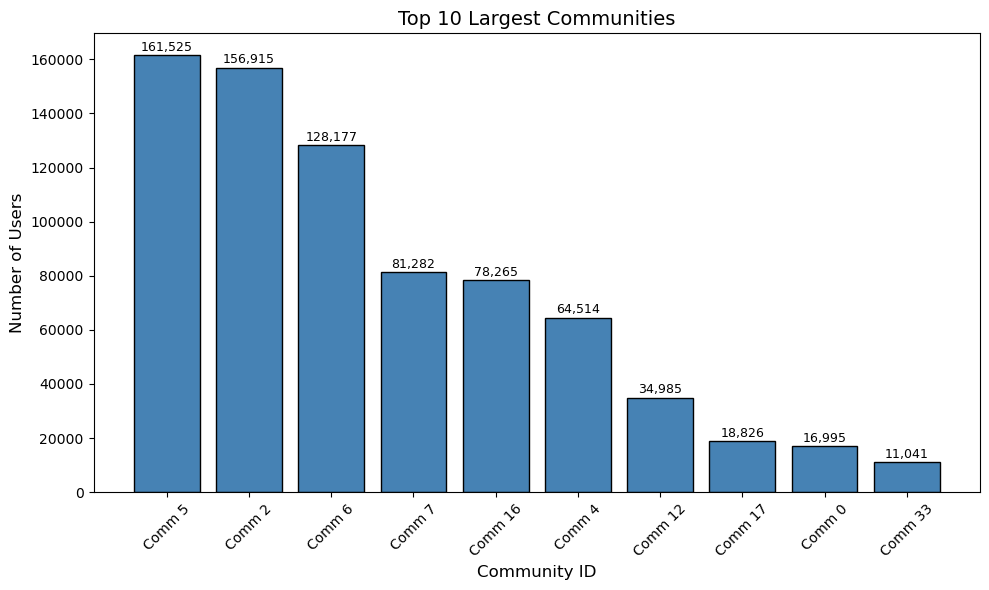

In [7]:
with open("data/louvain_partition.pkl", "rb") as f:
    louvain_partition = pickle.load(f)

community_sizes = Counter(louvain_partition.values())
top10 = community_sizes.most_common(10)

communities = [f"Comm {c}" for c, _ in top10]
sizes = [size for _, size in top10]

plt.figure(figsize=(10, 6))
plt.bar(communities, sizes, color='steelblue', edgecolor='black')
plt.title("Top 10 Largest Communities", fontsize=14)
plt.xlabel("Community ID", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.xticks(rotation=45)

for i, (bar, size) in enumerate(zip(communities, sizes)):
    plt.text(i, size + 500, f'{size:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("top10_communities.png", dpi=150)
plt.show()